In [1]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from pathlib import Path

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### EDA

Datasetet FER-2013 innehåller gråskalebilder (48x48 pixlar) av ansikten uppdelade i 7 klasser av ansiktsuttryck.

Datasetet är redan uppdelat i tränings- och testdata, så ingen egen train/test-split behövs.

Klasser: angry, disgust, fear, happy, neutral, sad, surprise

Antal bilder:
- Träning: 28 700 bilder
- Test: 7 200 bilder

Klasserna är tydligt obalanserade. 
Happy är den största klassen med 7 215 träningsbilder, medan disgust bara har 436. 

Det innebär att modellen riskerar att bli bättre på vanliga klasser och sämre på disgust.

In [2]:
# titta på datans struktur
# datasetet är redan uppdelat i train och test, så behöver inte göra egen train/test split
# 7 klasser: angry, disgust, fear, happy, neutral, sad, surprise
# Klasserna är obalanserade. Många fler happy bilder än disgust tex
# 28 700 träningsbilder och 7 200 testbilder

#happy: 7215 bilder
#disgust: 436 bilder

data_path = "data/FER-2013"

for split in ["train", "test"]:
    path = os.path.join(data_path, split)
    classes = [c for c in os.listdir(path) if not c.startswith(".")]    # så att vi inte får problem med .DS_Store på macOS
    print(f"\n{split}:")
    for c in sorted(classes):
        n = len(os.listdir(os.path.join(path, c)))
        print(f"  {c}: {n} bilder")


train:
  angry: 3995 bilder
  disgust: 436 bilder
  fear: 4097 bilder
  happy: 7215 bilder
  neutral: 4965 bilder
  sad: 4830 bilder
  surprise: 3171 bilder

test:
  angry: 958 bilder
  disgust: 111 bilder
  fear: 1024 bilder
  happy: 1774 bilder
  neutral: 1233 bilder
  sad: 1247 bilder
  surprise: 831 bilder


### Förbereda datan

Bilderna laddades in som numpy arrays och normaliserades till värden mellan 0 och 1.

Eftersom klasserna är obalanserade skapades ett balanserat subset med 300 bilder 
per klass, totalt 2100 bilder.

Subset delades upp i tränings- och valideringsdata:
- Träning: 1680 bilder (80%)
- Validering: 420 bilder (20%)

Testdatan (7178 bilder) behålls helt osedd tills den slutliga utvärderingen.

In [3]:
# Ladda in tränings- och testdata
train_dataset = keras.utils.image_dataset_from_directory(       # inbyggd Keras funktion som laddar in bilderna
    "data/FER-2013/train",
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    label_mode="int",
    shuffle=True,
    seed=42
)

test_dataset = keras.utils.image_dataset_from_directory(
    "data/FER-2013/test",
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    label_mode="int",
    shuffle=False,
    seed=42
)

class_names = train_dataset.class_names
print("Klasser:", class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
# Ladda in bilder som numpy arrays
# ett alternativ hade varit att använda image_dataset_from_directory() 
# men jag känner mig mer komfortable med numpy arrays

# 28 709 träningsbilder, 7 178 testbilder
# 48x48 pixlar med 1 kanal (gråskala)

def load_images_from_folder(base_path, class_names):
    X = []
    y = []
    
    for class_id, class_name in enumerate(class_names):
        folder = Path(base_path) / class_name
        for img_path in folder.glob("*.jpg"):
            img = image.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
            img_array = image.img_to_array(img)
            X.append(img_array)
            y.append(class_id)
    
    return np.array(X), np.array(y)

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

X_train_full, y_train_full = load_images_from_folder("data/FER-2013/train", class_names)
X_test, y_test = load_images_from_folder("data/FER-2013/test", class_names)

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train_full: (28709, 48, 48, 1)
y_train_full: (28709,)
X_test: (7178, 48, 48, 1)
y_test: (7178,)


In [5]:
# Normalisera pixelvärden från [0, 255] till [0, 1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

print("Min pixelvärde:", X_train_full.min())
print("Max pixelvärde:", X_train_full.max())

Min pixelvärde: 0.0
Max pixelvärde: 1.0


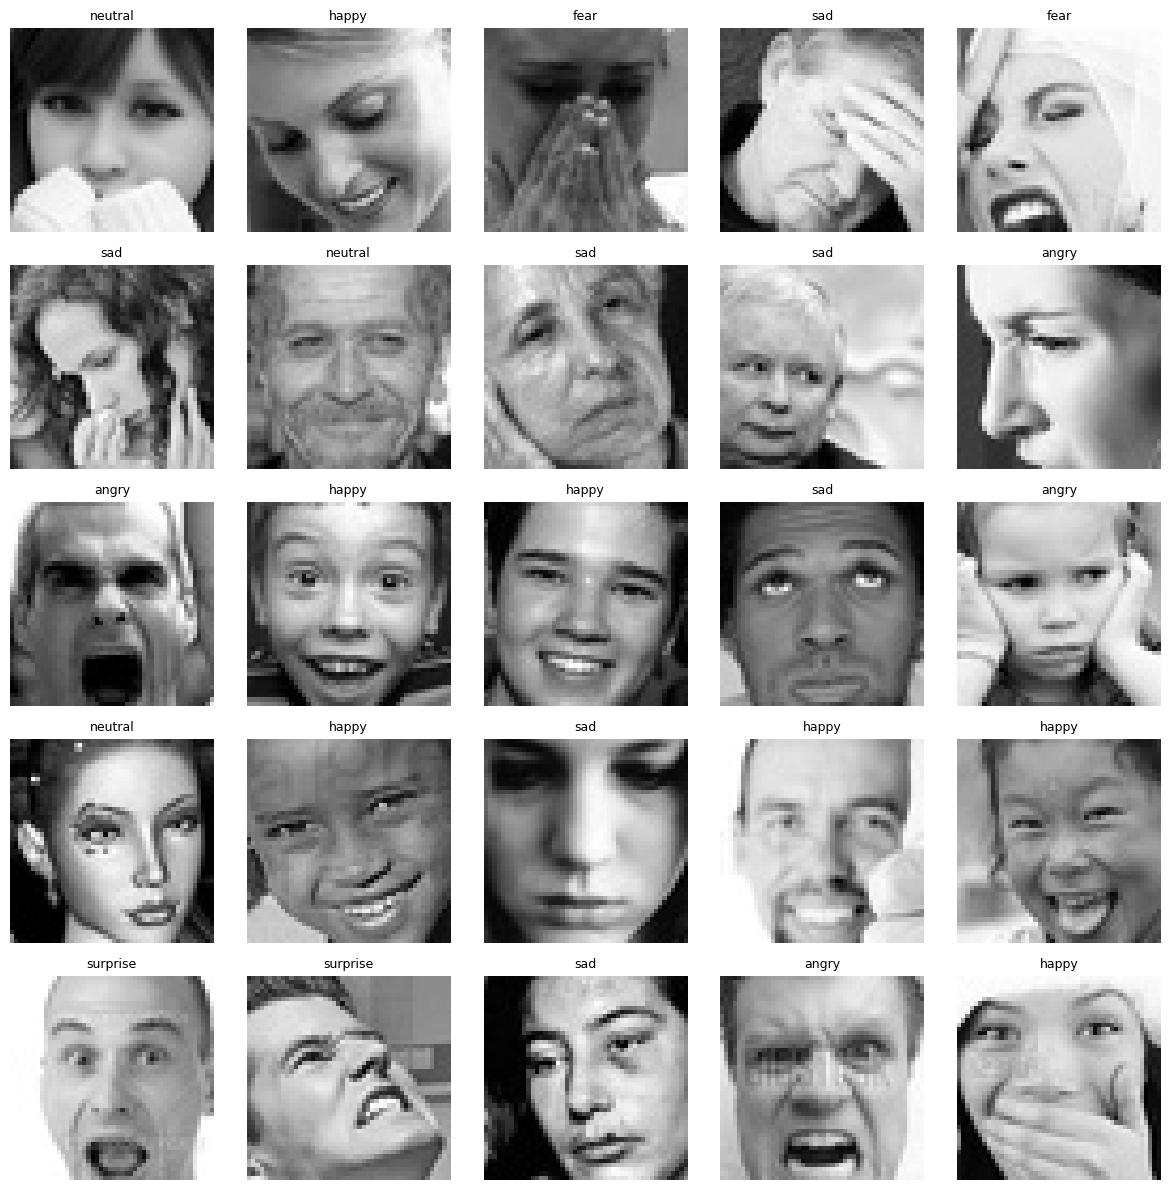

In [6]:
# titta på några exempelbilder
# tar ut 25 slumpmässiga bilder fråpn train

def plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index].squeeze(), cmap="gray")
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

plot_image_grid(X_train_full, y_train_full, class_names, n_images=25)

In [7]:
# Skapa ett balanserat subset av datan
# Använder 300 slumpmässiga bilder per klass
# så shapen blir 300 x 7, 48 x 48 pixlar och en kanal

def create_balanced_subset(X, y, samples_per_class=300, random_state=42):
    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    X_train_full,
    y_train_full,
    samples_per_class=300,
    random_state=42
)

print("X_subset:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)

X_subset: (2100, 48, 48, 1)
y_subset: (2100,)


In [8]:
# Delar upp subsetet i träning och validering 

X_train, X_val, y_train, y_val = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (1680, 48, 48, 1)
Val shape: (420, 48, 48, 1)


### Baseline-modell

Jag har medveter gjort baselinemodellen så enkel som möjligt, för att ha den som utgångspunkt mot de 
modellförbättringar jag gör sen. 

Modellen har:
- Bara ett Conv2D-lager per block (istället för två)
- Inget tredje Conv2D-block
- Ingen Dropout

Avsaknaden av Dropout innebär att modellen troligen kommer att overfitta (träningsaccuracy kommer vara högre än valideringsaccuracy).
Genom att sen förbättra modellen ska vi kunna få den att presetera bättre på ny data. 

Baseline-modellen tränades på subset (1680 träningsbilder, 420 valideringsbilder) i 15 epoker.

Träningen gav:
- Träningsaccuracy: 79.6%
- Valideringsaccuracy: 33.1%

Modellen visar tecken på både underfitting och overfitting samtidigt.
Valideringsaccuracy på 33.1% är låg, vilket tyder på underfitting. Modellen är för enkel för att lära sig. 

Samtidigt syns tydlig overfitting redan efter 2-3 epoker, där träningsaccuracy fortsätter klättra 
medan valideringsaccuracy planar ut. Dropout skulle antagligen ha hjälpt.

Om vi tittar per klass så ser vi stora skillnader i hur bra modellen känner igen olika ansiktsuttryck.

Bäst:
- surprise: 66.7% 
- disgust: 56.7% (Trots att det är den minsta klassen, så modellen har få bilder att lära sig på)

Sämst:
- angry: 16.7% (Angry och sad kanske blandas ihop?)
- sad: 18.3%

När vi tittar på några av de bilderna som klassificerades fel av vår baseline modell så ser vi att 
'neutral' är särskilt svår att klassificera. 
Vissa bilder tycker jag är genuint svåra att klassificera, även för ett mänskligt öga. 

In [9]:
# Bygg en baaseline
# CNN med ett Conv2D-lager per block och MaxPooling, följt av ett Dense-lager

def build_baseline_model(num_classes, learning_rate=0.001):
    model = keras.Sequential([
        keras.Input(shape=(48, 48, 1)),

        # Ingen Dropout till att börja med
        # Bara ett Conv2D-lager per block för baseline
        # MaxPooling krymper bilden. Det minskar antalet parametrar så modellen tränar snabbare
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Plattar ut 3D-tensor till 1D så att den kan matas in i Dense-lagret
        layers.Flatten(),

        # Denselagret på slutet
        layers.Dense(128, activation="relu"),

        # Ingen Dropout här
        # Använder softmax för att få sannorlikheter 
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

num_classes = len(class_names)
baseline_model = build_baseline_model(num_classes=num_classes)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Träna baseline modellen med 15 epoker och batch size 64

start_time = time.time()

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

baseline_training_time = time.time() - start_time
print(f"Träningstid för baseline på subset: {baseline_training_time / 60:.2f} minuter")

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1292 - loss: 1.9519 - val_accuracy: 0.1619 - val_loss: 1.9422
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.1815 - loss: 1.9268 - val_accuracy: 0.2024 - val_loss: 1.9536
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2893 - loss: 1.8303 - val_accuracy: 0.2476 - val_loss: 1.8976
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3607 - loss: 1.7197 - val_accuracy: 0.2619 - val_loss: 1.8758
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3970 - loss: 1.6244 - val_accuracy: 0.2929 - val_loss: 1.8496
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4315 - loss: 1.5369 - val_accuracy: 0.2881 - val_loss: 1.8542
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4655 - loss: 1.4462 - val_accuracy: 0.3000 - val_loss: 1.8750
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5173 - loss: 1.3438 - val_accuracy: 0.3048 - v

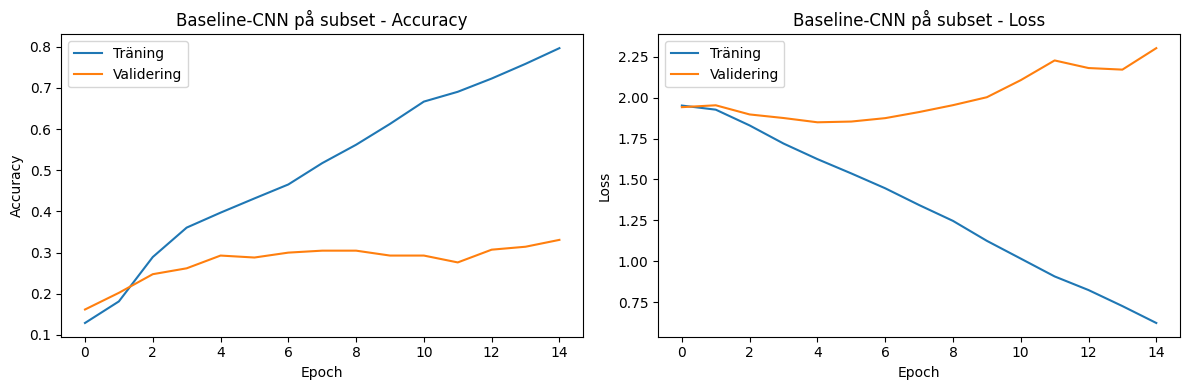

In [11]:
# Plotta träningskurvor för baseline
def plot_history(history, title="Träningshistorik"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    axes[0].plot(history.history["accuracy"], label="Träning")
    axes[0].plot(history.history["val_accuracy"], label="Validering")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    # Loss
    axes[1].plot(history.history["loss"], label="Träning")
    axes[1].plot(history.history["val_loss"], label="Validering")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, title="Baseline-CNN på subset")

In [12]:
# Förberedelse för felanalys på baseline modellen
# Starta med prediktioner på valideringsdatan

def predict_classes(model, X):
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    return y_pred, y_proba

baseline_val_pred, baseline_val_proba = predict_classes(baseline_model, X_val)

baseline_val_accuracy = accuracy_score(y_val, baseline_val_pred)
print(f"Baseline validation accuracy: {baseline_val_accuracy:.4f}")

Baseline validation accuracy: 0.3310


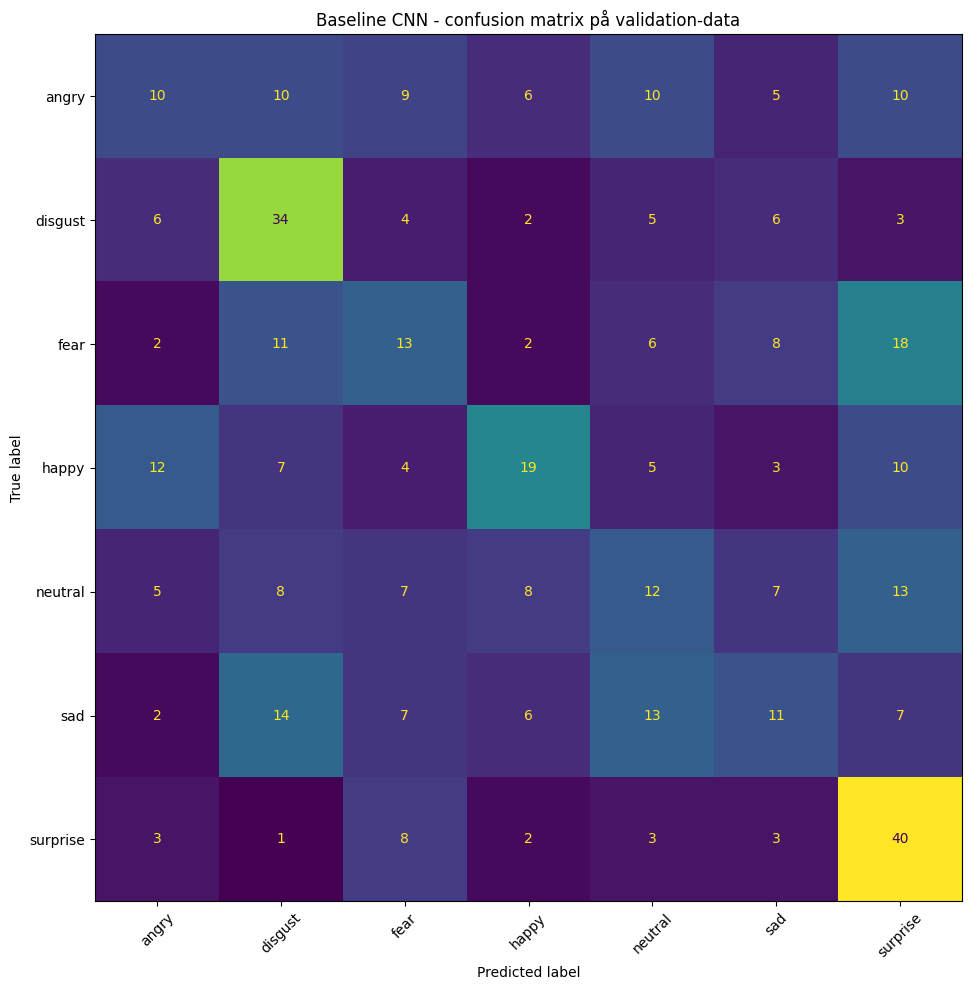

In [13]:
# Confusion matrix för valideringsdatan

# Ser här att: 
# surprise/surprise = 40 Modellen gissade rätt på 40 av surprise-bilderna. Surprise verkar vara den lättaste klassen att känna igen.
# angry/angry = 10 Modellen gissade bara rätt på 10 av angry-bilderna. Angry är svår att känna igen.
# fear/surprise = 18 Bilder som faktiskt var fear gissades som surprise. 

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    
    return cm

baseline_cm = plot_confusion_matrix(
    y_val,
    baseline_val_pred,
    class_names,
    title="Baseline CNN - confusion matrix på validation-data"
)

In [14]:
# Accuracy per klass
# Samman som ovan men i tabell. 
# Sämst: angry: 16.7%, bara 10 av 60 rätt
# Bäst: surprise: 66.7%, 40 av 60 rätt
# Disgust är vår minsta klass (bara 436 träningsbilder) men presterar näst bäst

def calculate_per_class_accuracy(cm, class_names):
    per_class = []
    for class_id, class_name in enumerate(class_names):
        total = cm[class_id].sum()
        correct = cm[class_id, class_id]
        accuracy = correct / total
        per_class.append({
            "class_id": class_id,
            "class_name": class_name,
            "total": total,
            "correct": correct,
            "accuracy": accuracy
        })
    
    df = pd.DataFrame(per_class).sort_values("accuracy")
    return df

baseline_per_class = calculate_per_class_accuracy(baseline_cm, class_names)
print(baseline_per_class)

   class_id class_name  total  correct  accuracy
0         0      angry     60       10  0.166667
5         5        sad     60       11  0.183333
4         4    neutral     60       12  0.200000
2         2       fear     60       13  0.216667
3         3      happy     60       19  0.316667
1         1    disgust     60       34  0.566667
6         6   surprise     60       40  0.666667


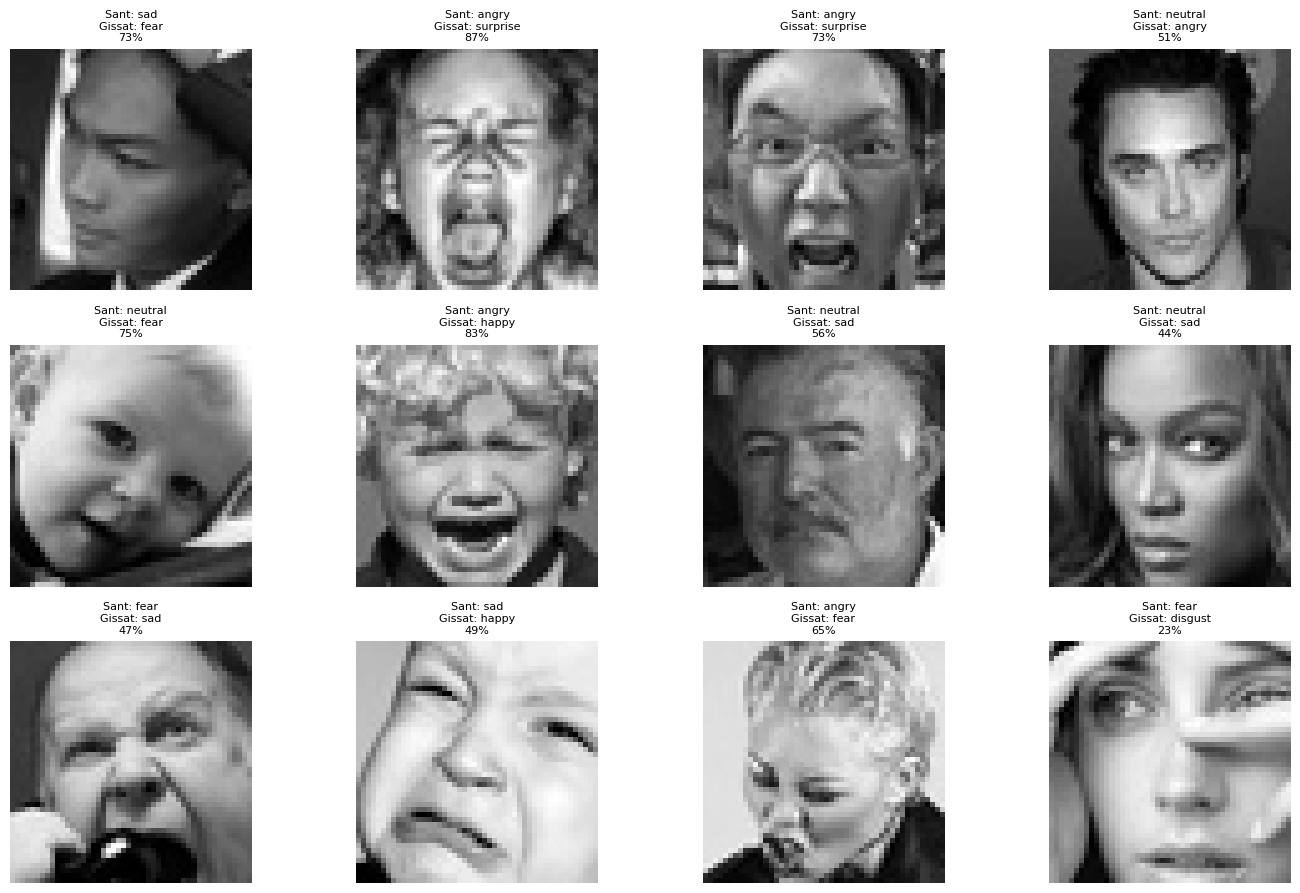

In [15]:
# Titta närmare på några felklassificerade bilder
# Här ser vi att tex 'neutral' är svårt för modellen att klassificera korrekt
# Men jag tittar även på dessa bilder och jag skulle själv ha svårt att 'korrekt'
# klassificera en del av dem. 

def plot_misclassified_examples(X, y_true, y_pred, y_proba, class_names, n_images=12, random_state=42):
    misclassified = np.where(y_true != y_pred)[0]
    
    rng = np.random.default_rng(random_state)
    indices = rng.choice(misclassified, size=min(n_images, len(misclassified)), replace=False)
    
    grid_size = int(np.ceil(np.sqrt(n_images)))
    
    plt.figure(figsize=(14, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index].squeeze(), cmap="gray")
        true_label = class_names[y_true[image_index]]
        pred_label = class_names[y_pred[image_index]]
        confidence = y_proba[image_index].max()
        plt.title(f"Sant: {true_label}\nGissat: {pred_label}\n{confidence:.0%}", fontsize=8)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

plot_misclassified_examples(
    X_val,
    y_val,
    baseline_val_pred,
    baseline_val_proba,
    class_names,
    n_images=12,
    random_state=42
)

### Förbättrar modellen med dropout, fler Conv2D lager och EarlyStopper


Den förbättrade modellen skiljer sig från baseline på tre sätt:
- Två Conv2D-lager per block istället för ett
- Ett tredje Conv2D-block med 128 filter
- Dropout efter varje block (0.25, 0.25, 0.30) och efter Dense-lagret (0.50)
- EarlyStopping med patience=5 för att undvika overfitting

Modellen tränades i 35 epochs innan EarlyStopping stoppade träningen.
Bästa val_loss uppnåddes vid epok 30.

Valideringsaccuracy nådde 34.7% mot baseline 33.1%. Det är fortfarande väldigt lågt. 

- Träningsaccuracy: 44%
- Valideringsaccuracy: 35%

Aaccuracy är ganska platt de första 18 epokerna. Sen går både träning och validering upp men vid 22-23 epoker så följer inte valideringen med träningen. 

Träningskuran fortsätter rakt upp men validering visar inte samma lutning, så vi har overfittat modellen på träningsdatan.
EarlyStopping gör sitt jobb och ser till att vi stannar vid 35 epoker.

Men jämfört med Baseline är den overfitting vi ser mindre. Skillnaden mellan träning och validering är cirka 10 procentenheter mot baseline.



In [16]:
def build_improved_model(num_classes, learning_rate=0.001):
    model = keras.Sequential([
        keras.Input(shape=(48, 48, 1)),

        # Block 1 - två Conv2D + Dropout
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2 - två Conv2D + Dropout
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3 - ett Conv2D + Dropout
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

improved_model = build_improved_model(num_classes=num_classes)
improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 729,703 (2.78 MB)

 Trainable params: 729,703 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Lägger till EarlyStopping så att vi inte tränar för länge och riskerar överanpassning

# EarlyStopping stoppade vid epoch 35 (patience=5, bästa val_loss var epoch 30 med 1.6968)
# Valideringsaccuracy nådde 34.7% mot baseline 33.1%. Fortfarande väldigt lågt. 

def make_early_stopping(patience=5):
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

start_time = time.time()

improved_history = improved_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[make_early_stopping(patience=5)]
)

improved_training_time = time.time() - start_time
print(f"Träningstid för förbättrad modell på subset: {improved_training_time / 60:.2f} minuter")

Epoch 1/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.1214 - loss: 1.9498 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 2/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.1226 - loss: 1.9461 - val_accuracy: 0.1452 - val_loss: 1.9459
Epoch 3/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.1405 - loss: 1.9460 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 4/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.1423 - loss: 1.9460 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 5/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.1381 - loss: 1.9460 - val_accuracy: 0.1571 - val_loss: 1.9453
Epoch 6/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.1440 - loss: 1.9461 - val_accuracy: 0.1524 - val_loss: 1.9449
Epoch 7/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.1601 - loss: 1.9457 - val_accuracy: 0.1500 - val_loss: 1.9437
Epoch 8/40
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.1732 - loss: 1.9451 - val_accuracy: 0.

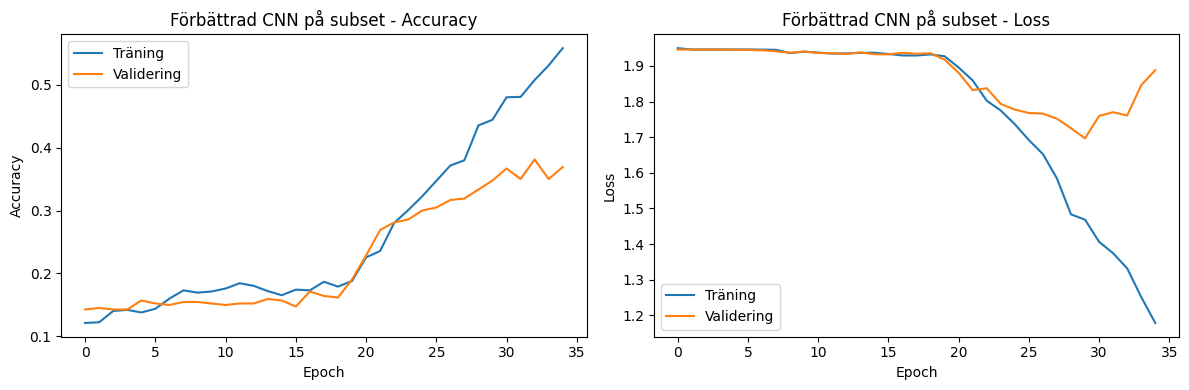

In [18]:
# accuracy är ganska platt de första 18 epokerna. sen går både träning och validering upp men vid 22-23 epoker 
# så följer inte valideringen med träningen. träningskuran fortsätter rakt upp men validering visar inte samma lutning. 
# Vi har overfittat modellen på träningsdatan
# EarlyStopping gör sitt jobb och ser till att vi stannar vid 35 epoker.

plot_history(improved_history, title="Förbättrad CNN på subset")

In [19]:
# Gör samma felanalys som för baseline modellen

improved_val_pred, improved_val_proba = predict_classes(improved_model, X_val)

improved_val_accuracy = accuracy_score(y_val, improved_val_pred)
print(f"Förbättrad modell validation accuracy: {improved_val_accuracy:.4f}")

Förbättrad modell validation accuracy: 0.3476


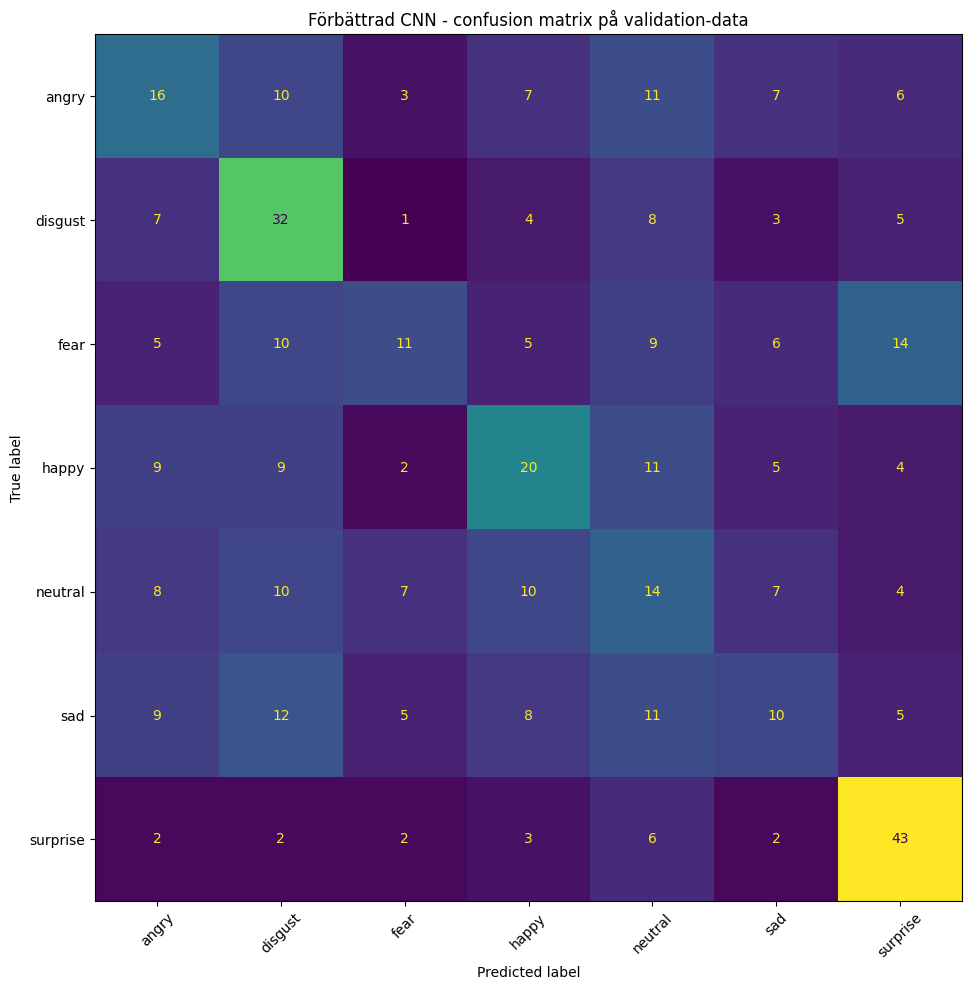

   class_id class_name  total  correct  accuracy
5         5        sad     60       10  0.166667
2         2       fear     60       11  0.183333
4         4    neutral     60       14  0.233333
0         0      angry     60       16  0.266667
3         3      happy     60       20  0.333333
1         1    disgust     60       32  0.533333
6         6   surprise     60       43  0.716667


In [20]:
# Och en confusion matrix 

# angry visar stor förbättring jämfört med baseline: från 16.7% till 26.7%
# sad, fear och neutral fortfarande svårast

improved_cm = plot_confusion_matrix(
    y_val,
    improved_val_pred,
    class_names,
    title="Förbättrad CNN - confusion matrix på validation-data"
)

improved_per_class = calculate_per_class_accuracy(improved_cm, class_names)
print(improved_per_class)

### Skala upp träningsdatan

Dags att använda all tillgänglig träningsdata (22,967 bilder).

Vi får:
- Träningsaccuracy: 63.7%
- Valideringsaccuracy: 59.4%
- EarlyStopping stoppade vid epoch 29, bästa val_loss vid epoch 24

Vi ser en tydlig förbättring jämfört med subsettet (34.8%).
Träningskurvorna ser snyggare ut, med träning och validering som följs åt 
de första 14 epokerna innan vi ser en mild overfitting

När jag först prövade att använda all träningsdata fastnade modellen på 25% accuracy vid 8 epoker. 
Efter lite felsökning upptäkte jag att jag hade normaliserat X_train_full två gånger. Det gav mig pixelvärden mellan 
0 - 0.004 istället för 0 - 1.

In [21]:
# Skala upp till all träningsdata
# X_train_full är redan normaliserad (0-1) sedan tidigare, dela INTE på 255 igen!


X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_full,  # redan normaliserad!
    y_train_full,
    test_size=0.2,      # 20% validering
    random_state=42,
    stratify=y_train_full
)

# Verifiera att normaliseringen är korrekt (max ska vara 1.0)
print("Min:", X_train_final.min())
print("Max:", X_train_final.max())

Min: 0.0
Max: 1.0


In [22]:
# Förbättra modellen, samma arkitektur som tidigare

tf.keras.backend.clear_session()    # återställ
tf.keras.utils.set_random_seed(42)

final_model = build_improved_model(num_classes=num_classes)

start_time = time.time()

# Träna på all träningsdata (22,967 bilder vs 1,680 i subset)
final_history = final_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=40,                  # max antal epochs
    batch_size=64,              # prövar med 64 som tidigare    
    callbacks=[make_early_stopping(patience=5)] # stoppar om loss inte förbättras på 5 epoker
)

final_training_time = time.time() - start_time
print(f"Träningstid för final modell på all data: {final_training_time / 60:.2f} minuter")

Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 46s 125ms/step - accuracy: 0.2501 - loss: 1.8110 - val_accuracy: 0.3103 - val_loss: 1.7244
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 49s 135ms/step - accuracy: 0.3420 - loss: 1.6674 - val_accuracy: 0.4129 - val_loss: 1.5572
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 141ms/step - accuracy: 0.3988 - loss: 1.5506 - val_accuracy: 0.4540 - val_loss: 1.4345
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 143ms/step - accuracy: 0.4411 - loss: 1.4467 - val_accuracy: 0.4744 - val_loss: 1.3448
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 52s 146ms/step - accuracy: 0.4688 - loss: 1.3870 - val_accuracy: 0.4990 - val_loss: 1.2871
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 53s 146ms/step - accuracy: 0.4901 - loss: 1.3390 - val_accuracy: 0.5153 - val_loss: 1.2670
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 52s 145ms/step - accuracy: 0.5029 - loss: 1.2956 - val_accuracy: 0.5333 - val_loss: 1.2225
Epoch 8/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 54s 149ms/step - accuracy: 0.5171 - loss: 1

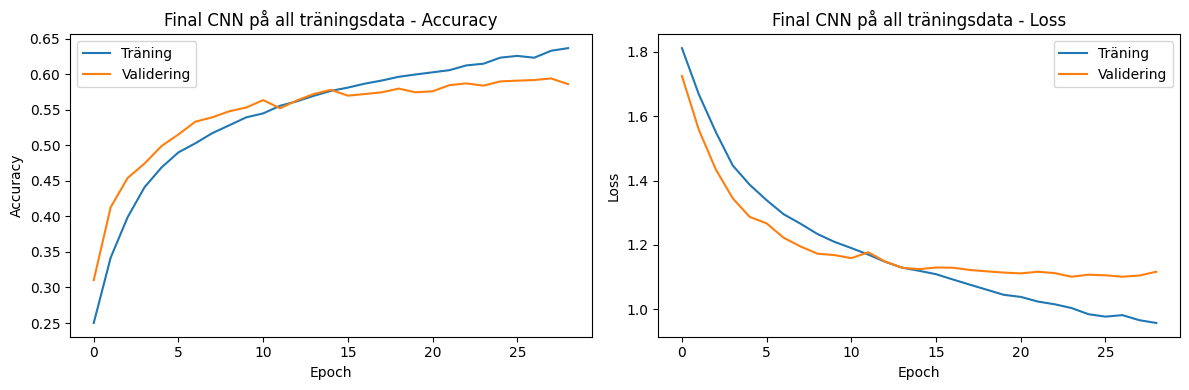

In [23]:
# Plottar träningsdatan
# ser mycket snyggare ut!
# overfitting efter ca 14 epoker
plot_history(final_history, title="Final CNN på all träningsdata")

### Utvärderar modellen på testdatan

Den slutliga modellen uppnår 58.3% accuracy på testdatan. Det är betydligt bättre än 
slumpmässig gissning (14.3% vid balanserade klasser) men det finns stor variation mellan klasser:
- Bäst: happy 84.4%, surprise 67.5%, neutral 61.9%
- Sämst: fear 23.4%, disgust 24.3%, angry 44.4%

Träningskurvorna för den slutliga modellen visar att träning och validering följs åt 
de första 14 epokerna, sedan börjar en mild overfitting. Skillnaden mellan tränings- 
och valideringsaccuracy är cirka 5 procentenheter, betydligt bättre än baseline som visade 
cirka 47 procentenheter. Dropout och EarlyStopping hjälpte tydligt.

Valideringsaccuracy (59.4%) och testaccuracy (58.3%) är nära varandra, vilket 
tyder på att modellen generaliserar väl på ny data.

Den största accurucy förbättringen kom från att skala upp till all träningsdata, från 34.8% 
på subset (jämfört med 33.1% på baseline på subset) till 59.4% på all data. 
Mer data hade större effekt än en mer komplex arkitektur.

Dropout minskade overfittingen dramatiskt men påverkade inte accuracy lika mycket.

Begränsningar:
- Fear och disgust är svåra klasser. Fear förväxlas ofta med surprise
- Disgust har få träningsbilder (436 stycken).
- Modellen tränas på 48x48 gråskalebilder vilket begränsar mängden information.

In [24]:
# Utvärdera den slutliga modellen på testdatan (final!)
final_test_pred, final_test_proba = predict_classes(final_model, X_test)

final_test_accuracy = accuracy_score(y_test, final_test_pred)
print(f"Final test accuracy: {final_test_accuracy:.4f}")

Final test accuracy: 0.5834


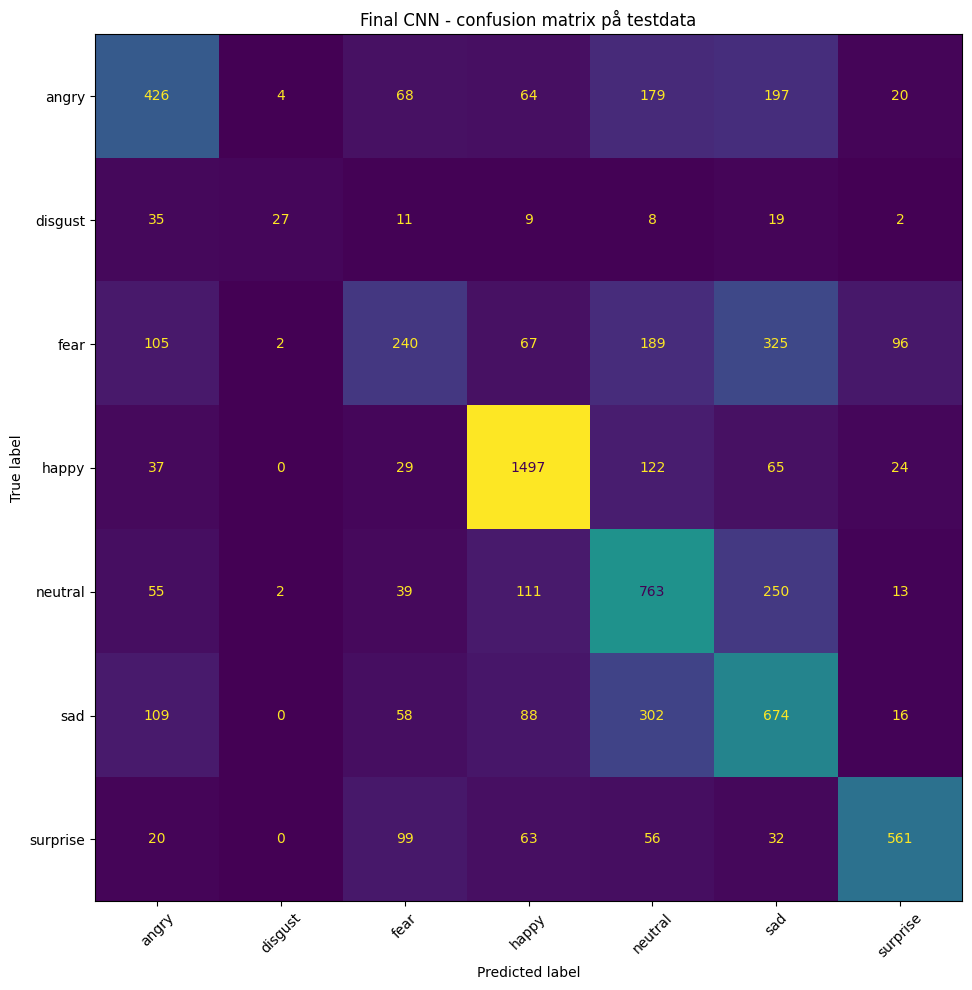

   class_id class_name  total  correct  accuracy
2         2       fear   1024      240  0.234375
1         1    disgust    111       27  0.243243
0         0      angry    958      426  0.444676
5         5        sad   1247      674  0.540497
4         4    neutral   1233      763  0.618816
6         6   surprise    831      561  0.675090
3         3      happy   1774     1497  0.843856


In [25]:
# Confusion matrix på testdatan
final_cm = plot_confusion_matrix(
    y_test,
    final_test_pred,
    class_names,
    title="Final CNN - confusion matrix på testdata"
)

# Accuracy per klass på testdatan (som vi har som funktion)
final_per_class = calculate_per_class_accuracy(final_cm, class_names)
print(final_per_class)

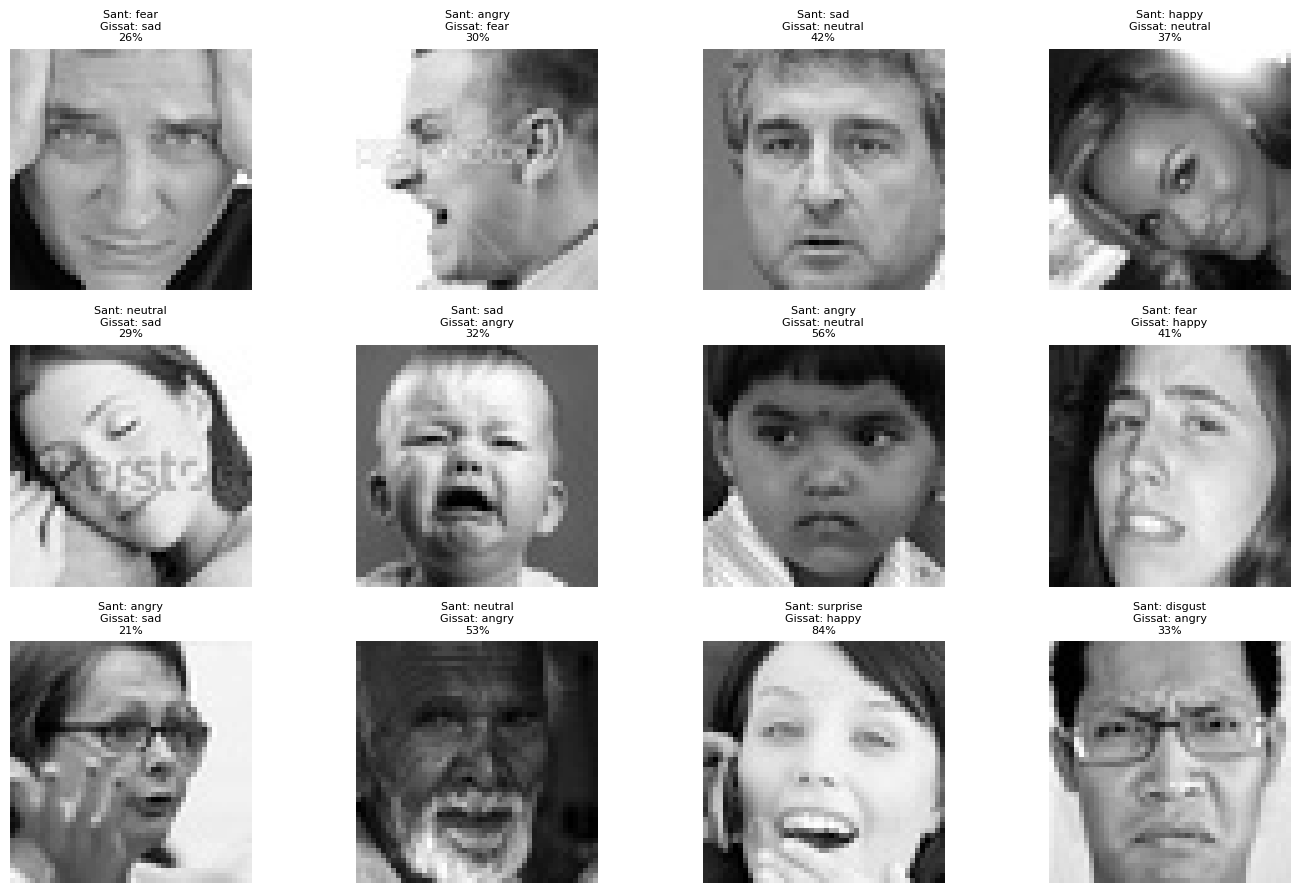

In [26]:
plot_misclassified_examples(
    X_test,
    y_test,
    final_test_pred,
    final_test_proba,
    class_names,
    n_images=12,
    random_state=42
)

### Prediktion på ny data

Jag tog fyra egna bilder och testade. Den första var angry och de tre andra var happy. 

Första gången gissade modellen fel på alla. 
Jag insåg då att träningsdatan var baserad på bilder där ansiktet fyllde upp nästan hela bilden.
Så jag croppade mina bilder så att ansiktena fyllde det mesta av rektangeln. 

När jag körde min predikt funktion igen blev resultatet bättre. 
Bild 1 happy med 80% säkerhet (det var angry)
Bild 2 happy med 60% säkerhet (det var happy)
Bild 3 happy med 87% säkerhet (det var happy)
Bild 4 happy med 100% säkerhet (det var happy)

Första försöket med okroppade bilder gav neutral med 27% säkerhet på alla bilder. 
Ansiktet fyllde för liten del av bilden. Efter cropping förbättrades resultaten.

Modellen tenderar dock att gissa happy, då happy är den största klassen i
träningsdatan (7215 bilder). Angry är en av de svårare klasserna, vilket stämmer 
med accuracy per klass (44.4% på testdatan).

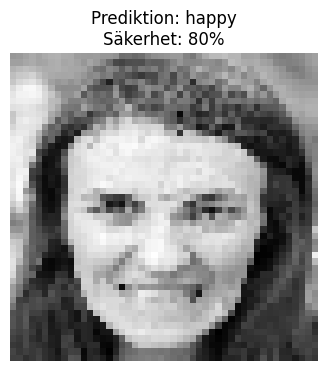

Prediktion: happy
Säkerhet: 80%


In [27]:
#Prövar fyra egna bilder. Den första är angry och de tre andra är happy. 
#Mina bilder är i färg. Tre är rakt framifrån och en har en lite vinklad profil.
#Modellen gissar happy på alla.

def predict_single_image(img_path, model, class_names):
    # Ladda in bilden och ändra storlek till 48x48 gråskala
    # target_size (48, 48) måste matcha träningsdatans storlek exakt
    # color_mode "grayscale" Träningsdatan var gråskala, så nya bilder måste också vara det
    # Om vi inte konverterar till gråskala får vi 3 kanaler (RGB) istället för 1, 
    # och modellen förväntar sig (48, 48, 1)
    img = keras.utils.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
    
    # Konvertera till numpy array och normalisera
    #img_to_array() konverterar till numpy array med shape (48, 48, 1)
    # / 255.0 normaliserar pixelvärdena från 0-255 till 0-1 (samma som träningsdatan)
    img_array = keras.utils.img_to_array(img) / 255.0
    
    # Lägg till en extra dimension
    # img_array har shape (48, 48, 1) men modellen förväntar sig (batch_size, 48, 48, 1)
    # expand_dims lägger till en extra dimension så shape blir (1, 48, 48, 1)
    # 1 betyder att vi skickar in en bild i taget
    img_array = np.expand_dims(img_array, axis=0)
    
    # Gör prediktion
    # model.predict() returnerar sannolikheter för varje klass
    # np.argmax() hämtar indexet för den högsta sannolikheten
    # .max() hämtar själva sannolikhetsvärdet
    y_proba = model.predict(img_array, verbose=0)
    y_pred = np.argmax(y_proba)
    confidence = y_proba[0].max()
    
    # Visa bilden och resultatet
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")        # visar originalbilden i gråskala
    plt.title(f"Prediktion: {class_names[y_pred]}\nSäkerhet: {confidence:.0%}", fontsize=12)
    plt.axis("off")
    plt.show()
    
    print(f"Prediktion: {class_names[y_pred]}")
    print(f"Säkerhet: {confidence:.0%}")

predict_single_image("test_images/egen_bild.png", final_model, class_names)

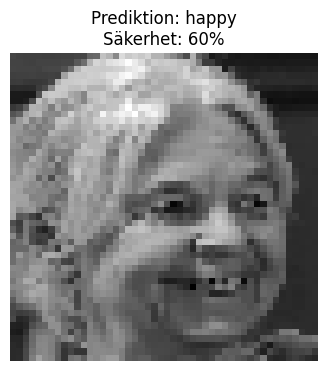

Prediktion: happy
Säkerhet: 60%


In [29]:
predict_single_image("test_images/egen_bild2.png", final_model, class_names)


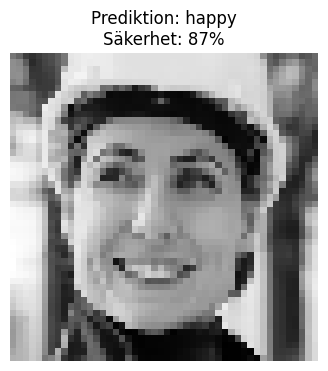

Prediktion: happy
Säkerhet: 87%


In [30]:
predict_single_image("test_images/egen_bild3.png", final_model, class_names)


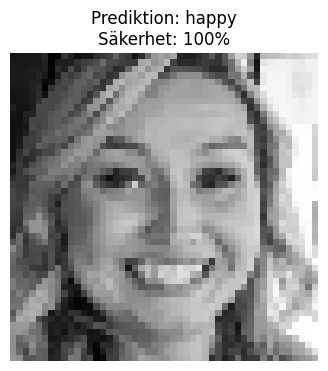

Prediktion: happy
Säkerhet: 100%


In [31]:
predict_single_image("test_images/egen_bild4.png", final_model, class_names)


### Analys av resultatet

Hur bra fungerar modellen?
Den slutliga modellen uppnår 58.3% accuracy på testdatan, vilket är betydligt bättre 
än slumpmässig gissning (14.3%). Det finns dock stor variation mellan klasser:
- Bäst: happy 84.4%, surprise 67.5%, neutral 61.9%
- Sämst: fear 23.4%, disgust 24.3%, angry 44.4%

Overfitting eller underfitting?
Baseline-modellen visade tydliga tecken på både underfitting och overfitting samtidigt, 
valideringsaccuracy på 33.1% mot träningsaccuracy 79.6%, en skillnad på cirka 47%.

Den förbättrade modellen med Dropout och EarlyStopping hanterade detta betydligt bättre. 
Träningskurvorna visar att träning och validering följs åt de första 14 epokerna, 
sedan börjar en mild overfitting. Skillnaden är 5%, en förbättring.

Skillnad mellan tränings- och testdata
Valideringsaccuracy (59.4%) och testaccuracy (58.3%) är mycket nära, vilket 
tyder på att modellen generaliserar väl till osedd data. 

Vad påverkar resultatet mest?
Den största förbättringen kom från att använda all träningsdata. Då gick valideringsaccuracy 
från 34.8% på det mindre datasetet, till 59.4% på all data. 

Dropout minskade overfittingen men påverkade inte accuracy lika mycket.
Att jag croppade mina egna bilder ordentligt visade hur viktigt det är att ny data liknar träningsdatan.

Begränsningar
- Fear och disgust är svåra klasser. Fear förväxlas ofta med surprise.
- Disgust har få träningsbilder (436 st).
- Modellen tränas på 48x48 gråskalebilder vilket begränsar mängden information.
- Transfer learning med en förtränad modell som MobileNetV2 hade troligen gett bättre resultat än 
vår ganska enkla CNN modell.

## Reflektion

Vad var svårast?
Det svåraste var att hålla koll på alla steg som behövs för att bygga, träna och 
förbättra en modell iterativt. Att förstå vad som behöver göras i vilken ordning. 
Subset först, sedan felanalys, därefter en förbättrad modell och sedan arbeta med
hela datasetet. Det tog tid att förstå hela flödet.

Jag gjorde också misstag på vägen:
- Dubbel normalisering (upptäckte det när modellen fastnade på 25% accuracy)
- Egna bilder som var för otydliga för prediktionen. Jag behövde fylla ut bilden med ansiktet.

Vad lärde du dig?
- Hur man bygger och förbättrar en CNN iterativt
- Att mer data kan ha större effekt än en mer komplex arkitektur
- Att se hur Dropout och EarlyStopping kan användas mot overfitting
- Att alltid verifiera datan innan träning (min/max-värden)
- Att träning på stor datamängd tar lång tid. Min modell tog över 20 minuter
att träna. Det innebär att varje ändring av modellen äter upp mycket tid om den ska köras igen.
- Att modellen fungerar bra på data som liknar träningsdatan men sämre på ny data som är lite annorlunda.

Vad hade du gjort annorlunda?
Jag skulle velat ha prövat transfer learning också, så att jag kunde testat MobileNetV2 på datan. 
En förtränad modell hade troligen gett bättre accuracy än 58%.

Betyg
Jag tycker att min inlämning motsvarar VG eftersom jag:
- Byggt en fungerande CNN-modell och utvärderat den
- Jämfört två modeller (baseline vs förbättrad) och förklarat skillnaderna
- Testat förändringar som påverkar prestanda (Dropout, fler lager, mer data)
- Tolkat träningskurvor och förklarat overfitting/underfitting
- Gjort prediktioner på ny data
- Reflekterat över uppgiften

In [ ]:
# Spara den tränade modellen
final_model.save("fer_model.keras")
print("Modellen sparad!")